In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from hierarchical_clustering_invariant import AgglomerativeClustering
from utils import *
import sklearn.cluster as cluster
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy.stats as stats
from scipy.special import gamma
from scipy.stats import multivariate_normal,f
import random

In [2]:
from hierarchical_clustering_adaptive_tau import AgglomerativeClustering_adaptivetau

In [15]:

n = 30
p = 10
mu = np.zeros(p)
sigma = 1
tau_values = np.linspace(0,5,20)
print(tau_values)
n_runs = 10
n_clusters = 3
# Data collection
results = []
bcss = []
X = generate_null_data(n,p,mu,sigma)
X,y = generate_data_barbers(3,12,1)
model = AgglomerativeClustering_adaptivetau(X, 0.05,tau_values,n_runs, n_clusters, n_trials=10)
model.choose_tau()
print(model.tau_star)
print((model.tau_prob))
model.fit_with_tau_star()

[0.         0.26315789 0.52631579 0.78947368 1.05263158 1.31578947
 1.57894737 1.84210526 2.10526316 2.36842105 2.63157895 2.89473684
 3.15789474 3.42105263 3.68421053 3.94736842 4.21052632 4.47368421
 4.73684211 5.        ]
0.2631578947368421
[8.82397221e-27 1.00000000e+00 6.44046471e-43 1.81684231e-44
 4.07936657e-10 6.23913393e-27 7.70782519e-42 5.38728195e-14
 1.31611653e-40 2.03849982e-17 1.72994463e-33 1.05175983e-15
 6.76565253e-34 2.99731915e-22 1.50013903e-27 8.58545073e-33
 8.44500484e-22 5.29995136e-29 3.73349586e-30 8.82397221e-27]


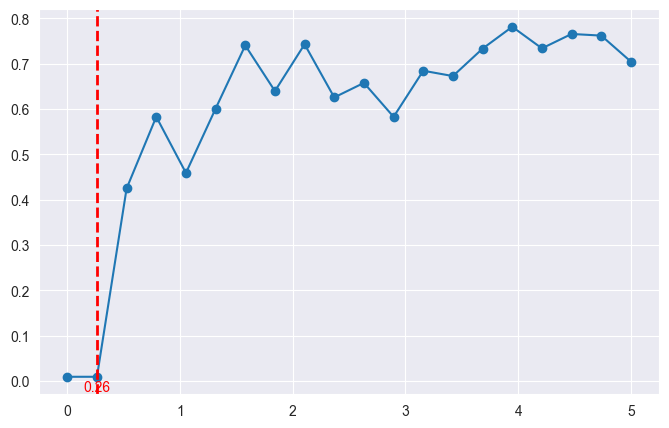

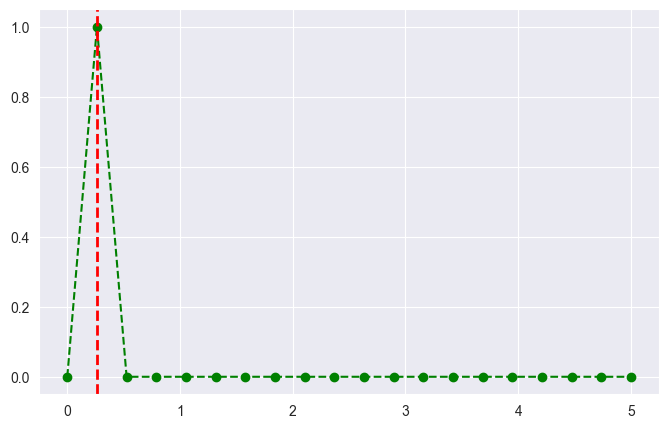

In [16]:
plt.figure(figsize=(8, 5))
plt.scatter(tau_values, model.scores)
plt.plot(tau_values, model.scores)
plt.axvline(model.tau_star, color="red", linestyle="--", linewidth=2)
plt.text(model.tau_star, plt.ylim()[0], f'{model.tau_star:.2f}',
         color='red', fontsize=10, ha='center', va='bottom')
plt.figure(figsize=(8, 5))
plt.scatter(tau_values, model.tau_prob, color='green')
plt.plot(tau_values, model.tau_prob, color="green" , linestyle="--")
plt.axvline(model.tau_star, color="red", linestyle="--", linewidth=2)

In [17]:
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[-1]
node = key[0].parent
model.merge_inference_F(node, ngrid=2000, ncoarse = 20, grid_width = 100)

(np.float64(0.860180907267634),
 np.float64(0.72057482485567),
 array([-124.87167339, -124.86141672, -124.85118103, ..., -120.23715954,
        -120.23661781, -120.23607648]))

In [33]:
def check_p_value_uniformity(n, p, sigma, K, epsilon, tau_list, layer, linkage="complete", num_trials=1000):
    p_values = []
    p_values_n = []
    mu = np.zeros(p)

    while len(p_values_n) < num_trials:
        X = generate_null_data(n, p, mu, sigma)
        model = AgglomerativeClustering_adaptivetau(X, epsilon, tau_list=tau_list, n_clusters=K, linkage=linkage, n_trials=1)
        model.choose_tau()
        model.fit_with_tau_star()
        

        winning_nodes = list(model.existing_clusters_log.keys())
        key = winning_nodes[layer]
        node = key[0].parent
        #c1 = model.K_clusters[0]
        #c2 = model.K_clusters[1]
        #p_value, obs, sel_corrected = model.merge_inference_F_random_pair_grid(c1,c2, grid_width=70, ncoarse=20, ngrid=2000)
        p_value, obs, sel_corrected = model.merge_inference_F_grid(node, grid_width=1, ncoarse=20,ngrid=2000)
        p_value_n = naive_p_value(X, K, layer, linkage)
        if not (np.isnan(p_value) and np.isnan(p_value_n)):
            p_values.append(p_value)
            p_values_n.append(p_value_n)
    p_values = np.array(p_values)
    p_values_n = np.array(p_values_n)

    # Histogram for both p-values
    plt.figure(figsize=(8, 5))
    plt.hist(p_values, bins=20, density=True, alpha=0.5, color="blue", edgecolor="black",
             label="Selection-based p-value")
    plt.hist(p_values_n, bins=20, density=True, alpha=0.5, color="orange", edgecolor="black", label="Naive p-value")
    plt.axhline(1, color='red', linestyle='dashed', linewidth=2, label="Uniform(0,1)")
    plt.xlabel("P-value")
    plt.ylabel("Density")
    plt.title("Histogram of P-values Under the Null Hypothesis")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.ecdfplot(p_values, color="blue", label="Selection-based p-values")
    sns.ecdfplot(p_values_n, color="orange", label="Naive p-values")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("P-value")
    plt.ylabel("ECDF")
    plt.title("Empirical CDF of P-values")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    # Q-Q Plot for both p-values
    plt.figure(figsize=(8, 5))
    sorted_p_values = np.sort(p_values)
    sorted_p_values_n = np.sort(p_values_n)
    theoretical_quantiles = np.linspace(0, 1, num_trials)

    plt.plot(theoretical_quantiles, sorted_p_values, marker='o', linestyle='', color="blue",
             label="Selection-based p-values")
    plt.plot(theoretical_quantiles, sorted_p_values_n, marker='o', linestyle='', color="orange", label="Naive p-values")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("Theoretical Uniform Quantiles")
    plt.ylabel("Empirical P-values")
    plt.title("Q-Q Plot: P-values vs. Uniform(0,1)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()



[-9.37835910e+00 -2.10203389e+01 -1.35776612e-02 -2.44640750e-04
 -2.09453151e+00 -1.09355478e-01 -6.33536791e+00 -6.21538543e+00
 -2.52861842e-01 -5.88411543e+00 -6.33301167e-01 -1.73894330e+01
 -1.77399285e+00 -7.20729947e-02 -1.03140111e-01 -4.61021517e+00
 -1.68474339e+01 -1.21461389e+00 -6.42028240e+00 -1.99805848e+00]
1e-05 1.0
[ -0.9685986  -10.15674089  -1.43601935  -1.33699122  -2.34246625
  -3.92557166  -9.39374924  -1.50156311  -7.38823877  -0.78725177
  -1.50488933  -0.89171554  -2.43814028  -8.65982854  -1.63612893
  -1.60441395  -5.71806151  -0.93751647  -2.10021992  -6.65103407]
1e-05 1.0
[ -0.86221435  -3.86972023  -5.94079366  -1.33922355  -9.9309673
  -0.10561646  -1.28123852  -2.97235348  -0.56586038  -4.74471462
  -6.68336588  -2.94448891 -12.05467505  -1.01825409  -5.81145779
  -4.7588084   -0.64747868  -1.71966403  -7.40030471  -2.97243909]
1e-05 1.0
[-3.99791262 -3.84648436 -6.05439059 -4.38852649 -4.05466077 -3.27966447
 -1.62040755 -4.64517924 -3.17277577 -2.40

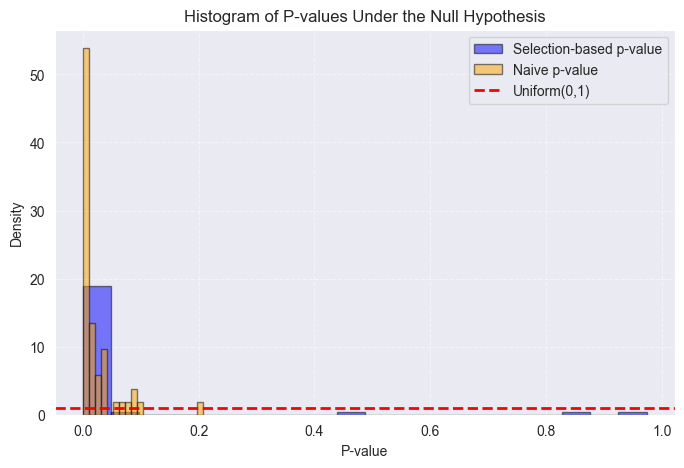

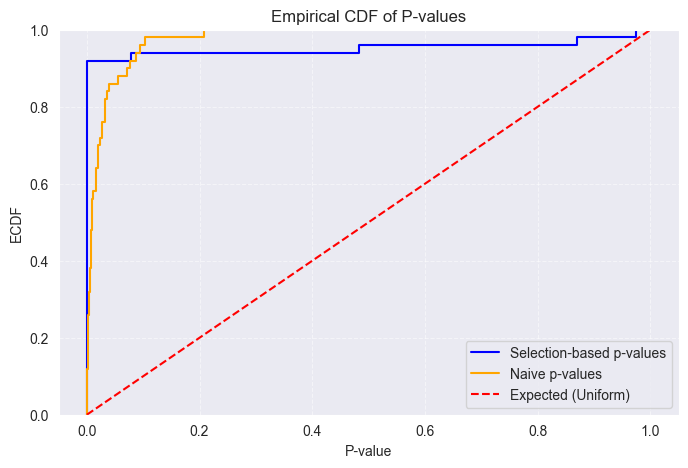

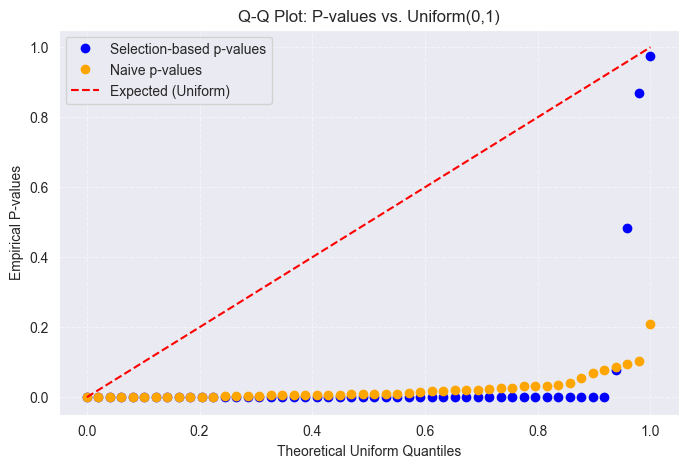

In [34]:
check_p_value_uniformity(15,2,1,3,1, tau_values, layer=-1,linkage="complete",num_trials=50)

In [7]:
def check_p_value_uniformity(n, p, sigma, K, epsilon, tau_list, layer, linkage="complete", num_trials=1000):
    p_values = []
    p_values_unadjusted =[]
    p_values_n = []
    mu = np.zeros(p)

    while len(p_values_n) < num_trials:
        X = generate_null_data(n, p, mu, sigma)
        model = AgglomerativeClustering_adaptivetau(X, epsilon, tau_list=tau_list, n_clusters=K, linkage=linkage)
        model.choose_tau()
        model.fit_with_tau_star()
        tau_star = model.tau_star

        winning_nodes = list(model.existing_clusters_log.keys())
        key = winning_nodes[layer]
        node = key[0].parent
        #c1 = model.K_clusters[0]
        #c2 = model.K_clusters[1]
        #p_value, obs, sel_corrected = model.merge_inference_F_random_pair_grid(c1,c2, grid_width=70, ncoarse=20, ngrid=2000)
        p_value, obs, sel_corrected = model.merge_inference_F_grid(node, grid_width=200, ncoarse=20,ngrid=2000)
        p_value_n = naive_p_value(X, K, layer, linkage)
        
        model_unadjusted = AgglomerativeClustering(X, n_clusters=K, linkage=linkage, tau=tau_star)
        model_unadjusted.fit()
        winning_nodes = list(model_unadjusted.existing_clusters_log.keys())
        key = winning_nodes[layer]
        node = key[0].parent
        
        p_value_unadj, _, _ = model_unadjusted.merge_inference_F_grid(node,grid_width = 150, ncoarse=20,ngrid=2000)
        
        
        if not (np.isnan(p_value_unadj) and np.isnan(p_value_n)):
            p_values.append(p_value)
            p_values_n.append(p_value_n)
            p_values_unadjusted.append(p_value_unadj)
    p_values = np.array(p_values)
    p_values_n = np.array(p_values_n)
    p_values_unadjusted = np.array(p_values_unadjusted)

    plt.figure(figsize=(8, 5))
    sns.ecdfplot(p_values, color="blue", label="Selection-based p-values")
    sns.ecdfplot(p_values_n, color="orange", label="Naive p-values")
    sns.ecdfplot(p_values_unadjusted, color="green", label="Unadjusted p-values")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("P-value")
    plt.ylabel("ECDF")
    plt.title("Empirical CDF of P-values")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    # Q-Q Plot for both p-values
    plt.figure(figsize=(8, 5))
    sorted_p_values = np.sort(p_values)
    sorted_p_values_n = np.sort(p_values_n)
    sorted_p_values_unadjusted = np.sort(p_values_unadjusted)
    theoretical_quantiles = np.linspace(0, 1, num_trials)

    plt.plot(theoretical_quantiles, sorted_p_values, marker='o', linestyle='', color="blue",
             label="Selection-based p-values")
    plt.plot(theoretical_quantiles, sorted_p_values_n, marker='o', linestyle='', color="orange", label="Naive p-values")
    plt.plot(theoretical_quantiles, sorted_p_values_unadjusted,marker='o', linestyle='', color="green", label="Unadjusted p-values")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("Theoretical Uniform Quantiles")
    plt.ylabel("Empirical P-values")
    plt.title("Q-Q Plot: P-values vs. Uniform(0,1)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()



1e-05 45.275421542225786
[-18.81745372 -18.6570532  -17.65918584  -2.27489081 -19.02047111
 -17.48527027 -26.87555779 -22.59523403 -12.77391814 -30.87933448
  -9.61205062 -21.06571594 -18.94988414 -24.80629879  -0.54138603
 -17.99132331  -5.4616105   -6.14646793 -27.25806153 -24.35179476]
1e-05 38.78823350365509
1e-05 49.254558400866706
[-1.64922407e+01 -2.09942485e+01 -2.24897981e+01 -5.20447990e+01
 -1.24446701e+00 -3.82729435e+01 -3.79882731e+01 -1.84024604e+01
 -1.93336576e+01 -3.16399151e+01 -3.37462872e+01 -2.18489511e+01
 -1.77879655e+01 -3.06888800e+01 -1.84045195e+01 -2.51123241e+01
 -8.58825412e+00 -2.46914257e+01 -9.68941916e-06 -6.17441354e+00]
1e-05 116.92859211101921
1e-05 48.973289739595266
[-34.51533423 -31.59798627 -30.44036867  -3.41078558 -28.17381576
 -16.75765272  -0.6279451  -16.54181598  -2.98655083 -54.4734401
 -22.76294786 -17.4080693  -25.41996516 -25.15339612 -28.2859018
 -18.2304432  -38.08839838 -42.26038235 -19.26595477  -0.22835005]
1e-05 37.0287128544104

/Users/judydw/Documents/GitHub/SI_HierarchicalClustering/src/utils.py:135: RuntimeWarning: invalid value encountered in scalar divide
  observed_target = (m - 2) * np.linalg.norm(P0 @ X, 'fro') ** 2 / np.linalg.norm(P1 @ X, 'fro') ** 2


1e-05 50.37903744276696
[-1.01442786e+01 -3.03568900e+01 -1.53543354e+01 -1.63393569e+01
 -1.83358122e-03 -2.84546620e-02 -1.79729681e+01 -3.83920090e+01
 -2.32764291e+01 -4.35492292e+01 -1.39934516e+01 -1.37900911e+01
 -4.13192208e+01 -3.48872538e-01 -1.76292168e+01 -2.43499909e+01
 -3.29244145e+01 -4.26411438e+00 -2.59049614e+01 -3.68670808e+01]
1e-05 47.60487588217346
1e-05 39.11630564802537
[-1.66932774e+01 -2.75066949e+00 -1.56240627e+00 -2.29230289e+01
 -3.84231902e-04 -1.17662209e+01 -7.45024640e-02 -2.32730950e+01
 -2.09252966e+01 -3.45206470e-07 -1.69182092e+01 -1.48922684e+01
 -1.62997763e+01 -1.70139964e+01 -5.33678745e+01 -1.80267718e-03
 -8.20985244e-01 -1.62169277e+01 -2.27913183e+01 -4.12471243e+01]
1e-05 72.45362713477391
1e-05 30.39401403939121
[ -9.71287     -3.62827298 -22.0389543  -18.5971008  -12.86419284
 -31.21994354 -36.58997252 -22.37393069  -2.19305201 -29.15772429
  -0.9248802  -25.45456095  -3.29937642  -1.76776997 -20.98813587
  -8.2869387  -27.80429411 -44

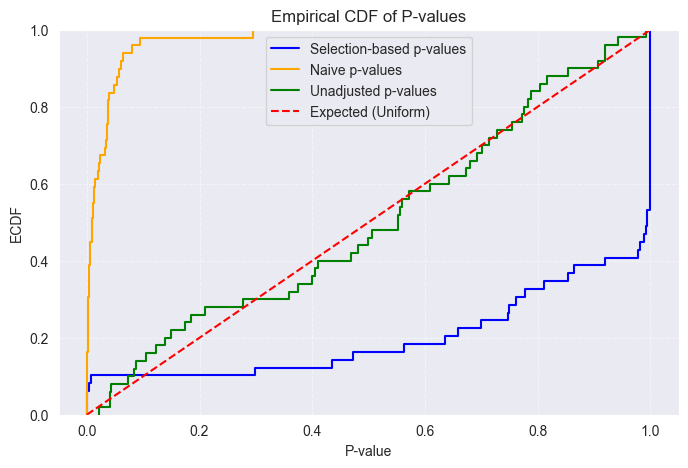

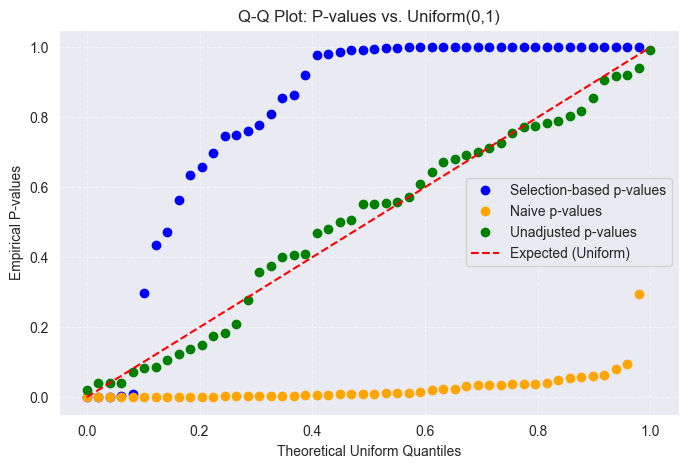

In [8]:
check_p_value_uniformity(15,2,1,3,0.1,tau_values, layer=-1,linkage="complete",num_trials=50)

In [1]:
tau_values = [0.005,0.007,0.01,0.025,0.05,0.075,0.1,0.25,0.5,0.75,1,2,5]
check_p_value_uniformity(15,10,1,3,5, tau_values, layer=15,linkage="complete",num_trials=100)

NameError: name 'check_p_value_uniformity' is not defined

In [2]:
check_p_value_uniformity(30,10,1,3,0.5, tau_values, layer=-1,linkage="complete",num_trials=100)

NameError: name 'check_p_value_uniformity' is not defined

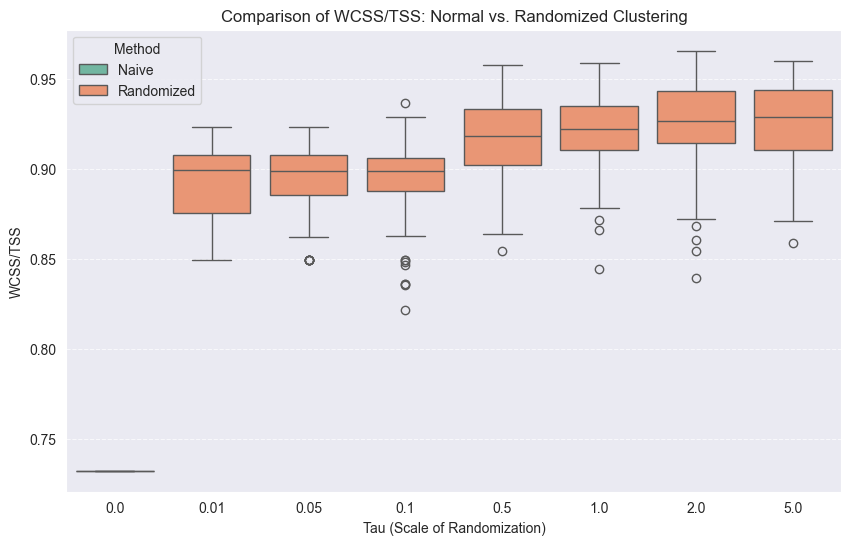

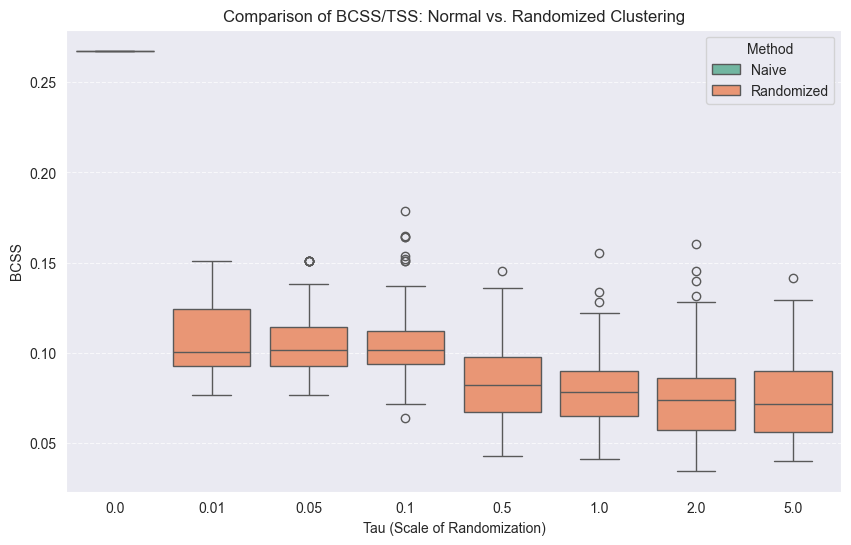

In [5]:
random.seed(10)
n = 30
p = 10
mu = np.zeros(p)
sigma = 1
tau_values = [0,0.01,0.05, 0.1,0.5,1,2,5]
n_runs = 100
n_clusters = 3
# Data collection
results = []
bcss = []
X = generate_null_data(n,p,mu,sigma)
for tau in tau_values:
    for _ in range(n_runs):
        #X, y = make_blobs(n_samples=n, centers=3, cluster_std=1)
        #X, y = generate_data_barbers(10,6,1)
        tss = np.sum((X - np.mean(X, axis=0)) ** 2)
        if tau != 0:
            # Randomized hierarchical clustering
            randomized_clustering = AgglomerativeClustering(X, n_clusters=n_clusters, tau=tau)
            randomized_clustering.fit()
            randomized_score = randomized_clustering.compute_wcss()
            bcss_score = randomized_clustering.compute_bcss()
            results.append({'Tau': tau, 'Method': 'Randomized', 'WCSS/TSS': randomized_score / tss})
            bcss.append({'Tau': tau, 'Method': 'Randomized', 'BCSS/TSS': bcss_score / tss})
        else:
            naive = cluster.AgglomerativeClustering(n_clusters=n_clusters)
            naive_labels = naive.fit_predict(X)
            naive_score = 0
            for k in range(n_clusters):
                cluster_points = X[naive_labels == k]
                if len(cluster_points) > 0:
                    center = np.mean(cluster_points, axis=0)
                    naive_score += np.sum((cluster_points - center) ** 2)
            results.append({'Tau': tau, 'Method': "Naive", 'WCSS/TSS': naive_score / tss})
            bcss.append({'Tau': tau, 'Method': "Naive", 'BCSS/TSS': (tss - naive_score) / tss})

# Convert results to a DataFrame
df = pd.DataFrame(results)
df_bcss = pd.DataFrame(bcss)

# Create side-by-side boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Tau', y='WCSS/TSS', hue='Method', palette='Set2')
plt.title('Comparison of WCSS/TSS: Normal vs. Randomized Clustering')
plt.xlabel('Tau (Scale of Randomization)')
plt.ylabel('WCSS/TSS')
plt.legend(title='Method',loc = 'upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_bcss, x='Tau', y='BCSS/TSS', hue='Method', palette='Set2')
plt.title('Comparison of BCSS/TSS: Normal vs. Randomized Clustering')
plt.xlabel('Tau (Scale of Randomization)')
plt.ylabel('BCSS')
plt.legend(title='Method',loc = 'upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [6]:
med = (
    df.groupby(['Tau','Method'])['WCSS/TSS']
      .median()
      .unstack('Method')
      .rename(columns={'Naive':'Naive_median','Randomized':'Rand_median'})
      .reset_index()
      .sort_values('Tau')
)
rand_curve = (
    med.loc[med['Tau']>0, ['Tau','Rand_median']]
    .copy()
    .sort_values('Tau')
)

taus = rand_curve['Tau'].to_numpy()
ys   = rand_curve['Rand_median'].to_numpy()

def pick_tau_by_max_adjacent_gap(taus, ys):
    gaps = np.abs(np.diff(ys))
    idx = np.argmax(gaps)
    return taus[idx], {'gap': float(gaps[idx])}
def pick_tau_by_second_difference(taus, ys):
    taus = np.asarray(taus, dtype=float)
    ys   = np.asarray(ys, dtype=float)
    second_diff = []
    for j in range(1, len(taus)-1):
        h1 = taus[j] - taus[j-1]
        h2 = taus[j+1] - taus[j]

        val = (ys[j-1] - 2*ys[j] + ys[j+1]) / ((0.5*(h1+h2))**2)
        second_diff.append(val)

    second_diff = np.array(second_diff)
    idx = np.argmax(np.abs(second_diff)) + 1 

    return taus[idx], {"second_diff": float(second_diff[idx-1])}
#tau_gap, info_gap = pick_tau_by_max_adjacent_gap(taus, ys)
tau_elbow, info_elbow = pick_tau_by_second_difference(taus, ys)
print(f"τ* = {tau_elbow}, second_diff = {info_elbow['second_diff']:.4f}")

τ* = 0.1, second_diff = 0.3838


1e-05 18.337112421479116
1e-05 10.725146609339912
1e-05 19.290902745213216
1e-05 13.98840285472144
1e-05 10.381368977070903
1e-05 15.87845642893919
1e-05 14.594156928485436
1e-05 16.243975924666827
1e-05 11.13136819711789
1e-05 10.807989319815858
1e-05 16.268075872124456
1e-05 14.114726675357009
1e-05 13.246401949624971
1e-05 18.063592407550303
1e-05 10.800432139452312
1e-05 15.99877464342775
1e-05 19.453687744596238
1e-05 13.082384506487893
1e-05 10.73265641435163
1e-05 11.038319263850893
1e-05 12.497602170491062
1e-05 14.215494670730514
1e-05 13.701482575642409
1e-05 10.76926755701552
1e-05 15.337600760848538
1e-05 11.02852136859834
1e-05 15.95053228886481
1e-05 10.798152412229568
1e-05 14.255719683166763
1e-05 15.474547992444059
1e-05 14.129018096611443
1e-05 14.626853888144526
1e-05 12.91834263384747
1e-05 14.383108865503626
1e-05 10.892375034426447
1e-05 15.19529793470429
1e-05 10.868648593014179
1e-05 14.191989850361722
1e-05 13.46082645928718
1e-05 16.61765613909921
1e-05 21.357

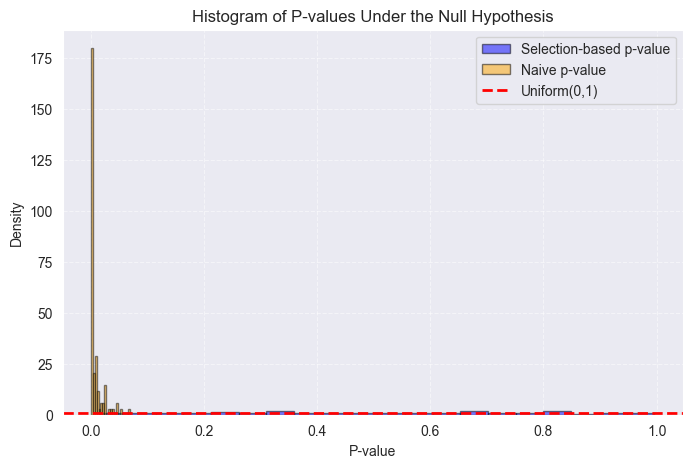

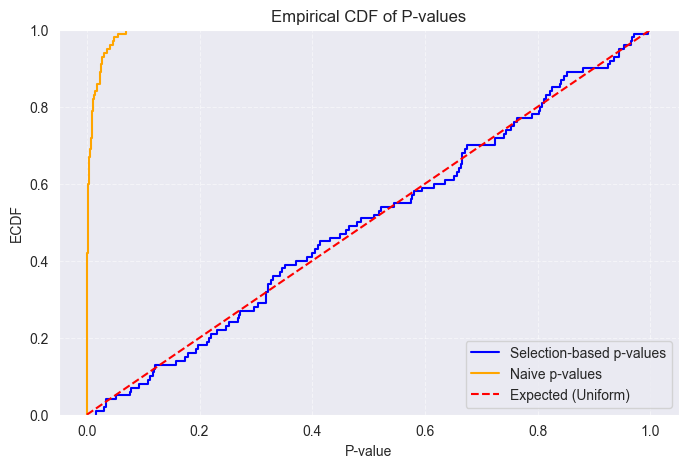

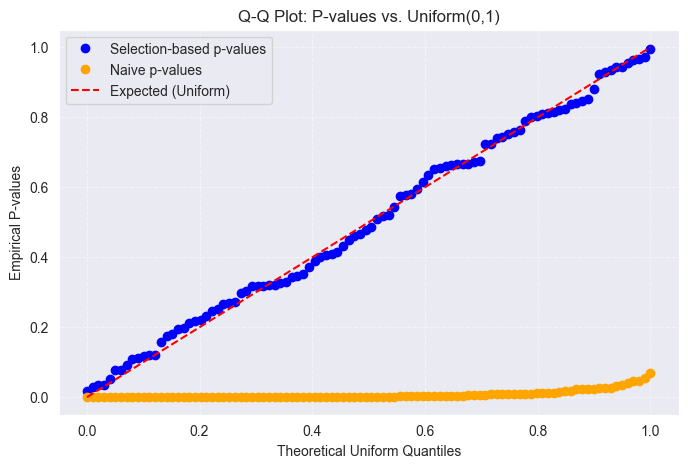

In [42]:
check_p_value_uniformity(n,p,sigma,n_clusters,tau_elbow,-1,num_trials=100)

In [43]:
def check_p_value_uniformity_sameX(X, n, p, sigma, K, tau, layer, linkage="complete", num_trials=100):
    p_values = []
    p_values_n = []
    mu = np.zeros(p)
    while len(p_values_n) < num_trials:
        model = AgglomerativeClustering(X, tau=tau, n_clusters=K, linkage=linkage)
        model.fit()

        c1 = model.K_clusters[0]
        c2 = model.K_clusters[1]
        p_value, obs, sel_corrected = model.merge_inference_F_random_pair_grid(c1,c2, grid_width = 150, ncoarse=30, ngrid=2000)
        p_value_n = naive_p_value(X, K, layer, linkage)
        if not (np.isnan(p_value) and np.isnan(p_value_n)):
            p_values.append(p_value)
            p_values_n.append(p_value_n)
    p_values = np.array(p_values)
    p_values_n = np.array(p_values_n)

    # Histogram for both p-values
    plt.figure(figsize=(8, 5))
    plt.hist(p_values, bins=20, density=True, alpha=0.5, color="blue", edgecolor="black",
             label="Selection-based p-value")
    plt.hist(p_values_n, bins=20, density=True, alpha=0.5, color="orange", edgecolor="black", label="Naive p-value")
    plt.axhline(1, color='red', linestyle='dashed', linewidth=2, label="Uniform(0,1)")
    plt.xlabel("P-value")
    plt.ylabel("Density")
    plt.title("Histogram of P-values Under the Null Hypothesis")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.ecdfplot(p_values, color="blue", label="Selection-based p-values")
    sns.ecdfplot(p_values_n, color="orange", label="Naive p-values")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("P-value")
    plt.ylabel("ECDF")
    plt.title("Empirical CDF of P-values")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    # Q-Q Plot for both p-values
    plt.figure(figsize=(8, 5))
    sorted_p_values = np.sort(p_values)
    sorted_p_values_n = np.sort(p_values_n)
    theoretical_quantiles = np.linspace(0, 1, num_trials)

    plt.plot(theoretical_quantiles, sorted_p_values, marker='o', linestyle='', color="blue",
             label="Selection-based p-values")
    plt.plot(theoretical_quantiles, sorted_p_values_n, marker='o', linestyle='', color="orange", label="Naive p-values")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("Theoretical Uniform Quantiles")
    plt.ylabel("Empirical P-values")
    plt.title("Q-Q Plot: P-values vs. Uniform(0,1)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()


1e-05 19.67166495637328
1e-05 15.017564230728155
1e-05 18.673935786127032
1e-05 22.083908084749623
1e-05 19.36700748323576
1e-05 21.37156310108974
1e-05 18.32595632391688
1e-05 16.785810664418268
1e-05 17.21180233853065
1e-05 16.53763559900011
1e-05 17.13233557014904
1e-05 17.19345409238106
1e-05 14.89863937128396
1e-05 14.417354416650806
1e-05 17.66500476855291
1e-05 19.00384879314602
1e-05 18.92844950957077
1e-05 17.661109642084917
1e-05 18.16312734933191
1e-05 19.456961543706583
1e-05 20.230019308478276
1e-05 14.82915111470374
1e-05 20.06956491663612
1e-05 17.744322300214066
1e-05 19.55853413026631
1e-05 15.114379743903097
1e-05 19.781405509604802
1e-05 15.051131765166282
1e-05 14.70452058573207
1e-05 16.349621775600692
1e-05 19.478034342855757
1e-05 18.74738535050621
1e-05 17.118801697993863
1e-05 19.980425175395567
1e-05 18.281118425582054
1e-05 18.61905998475508
1e-05 16.544230015652833
1e-05 18.116430542418065
1e-05 17.981012335444234
1e-05 15.780004425810446
1e-05 20.0558478873

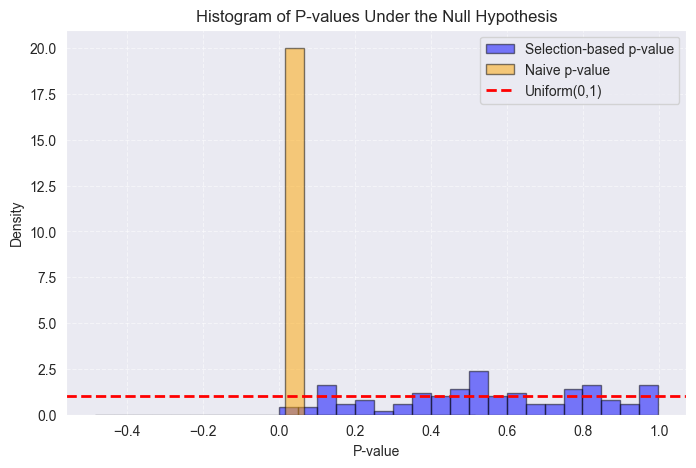

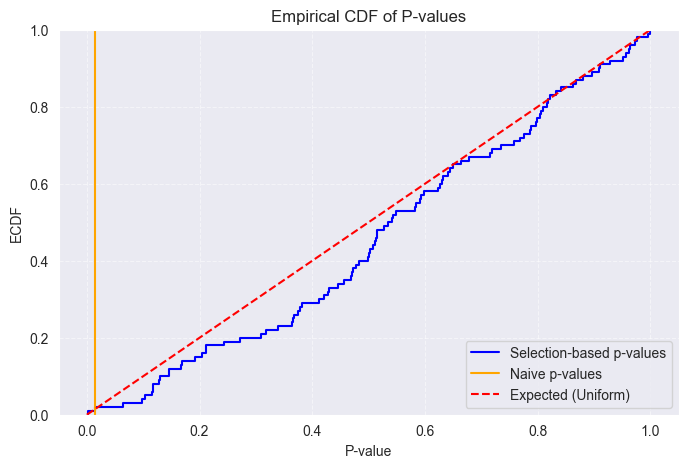

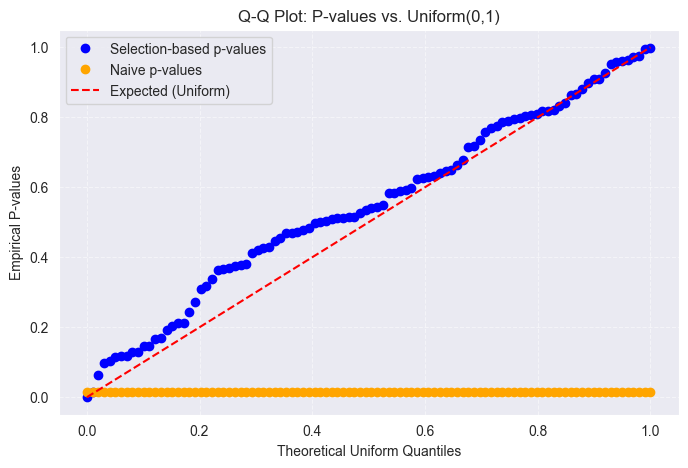

In [44]:
check_p_value_uniformity_sameX(X,n,p,sigma,n_clusters,tau_elbow,-1)